In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [35]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/eneskosar19
/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification
/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification
/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification/sad_person_face
/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification/happy_person_face
/kaggle/input/datasets/aravindanr22052001


In [37]:
happy_path = "/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification/happy_person_face"

sad_path = "/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification/sad_person_face"

print("Happy Images :", len(os.listdir(happy_path)))
print("Sad Images :", len(os.listdir(sad_path)))

Happy Images : 92
Sad Images : 73


In [38]:
categories = ["happy_person_face", "sad_person_face"]

dataset_path = "/kaggle/input/datasets/eneskosar19/happy-or-sad-binary-image-classification/face_classification"

data = []
labels = []

IMG_SIZE = 64

for category in categories:

    path = os.path.join(dataset_path, category)

    label = categories.index(category)

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            data.append(image)

            labels.append(label)

        except:
            pass

print("Images Loaded Successfully")
print("Total Images :", len(data))

Images Loaded Successfully
Total Images : 165


In [39]:
print("Happy Images :", labels.count(0))
print("Sad Images :", labels.count(1))

Happy Images : 92
Sad Images : 73


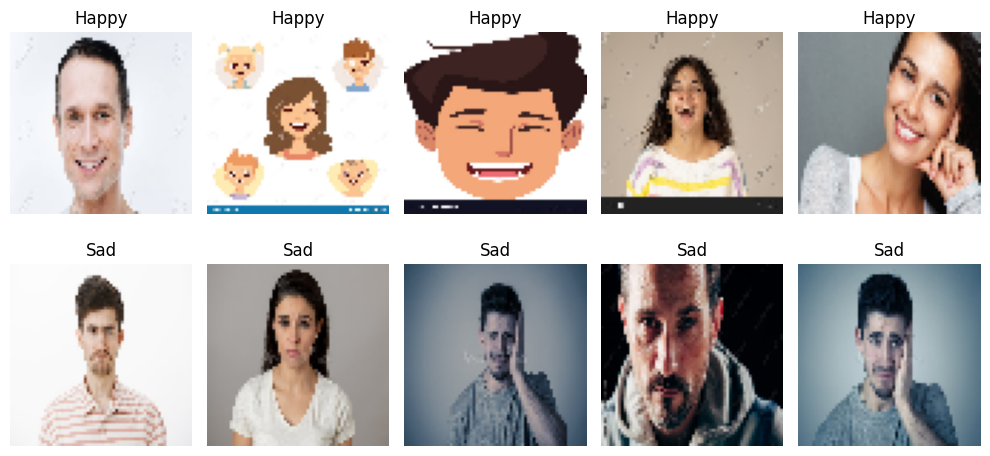

In [40]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(cv2.cvtColor(data[i], cv2.COLOR_BGR2RGB))
    plt.title("Happy")
    plt.axis("off")

for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(cv2.cvtColor(data[92+i], cv2.COLOR_BGR2RGB))
    plt.title("Sad")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
X = np.array(data) / 255.0
y = np.array(labels)

print("Image Dataset Shape :", X.shape)
print("Labels Shape :", y.shape)

Image Dataset Shape : (165, 64, 64, 3)
Labels Shape : (165,)


In [42]:
X_flat = X.reshape(len(X), -1)

print("Flattened Shape :", X_flat.shape)

Flattened Shape : (165, 12288)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 132
Testing Samples : 33


In [44]:
print(X.shape)
print(X_flat.shape)
print(len(X_train))
print(len(X_test))

(165, 64, 64, 3)
(165, 12288)
132
33


## Logistic Regression

Logistic Regression is trained to classify facial images into Happy and Sad categories. The model learns the relationship between image features and emotion labels.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

start_time = time.time()

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_time = time.time() - start_time

In [46]:
lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_acc*100,2), "%")
print("Training Time :", round(lr_time,4), "seconds")

Logistic Regression Accuracy : 72.73 %
Training Time : 14.5334 seconds


## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.

In [48]:
from sklearn.ensemble import RandomForestClassifier
import time

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_time = time.time() - start_time

In [49]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_acc*100,2), "%")
print("Training Time :", round(rf_time,4), "seconds")

Random Forest Accuracy : 75.76 %
Training Time : 0.4945 seconds


## Support Vector Machine (SVM)

SVM is trained to classify facial images into Happy and Sad categories by finding the optimal decision boundary between the two classes.
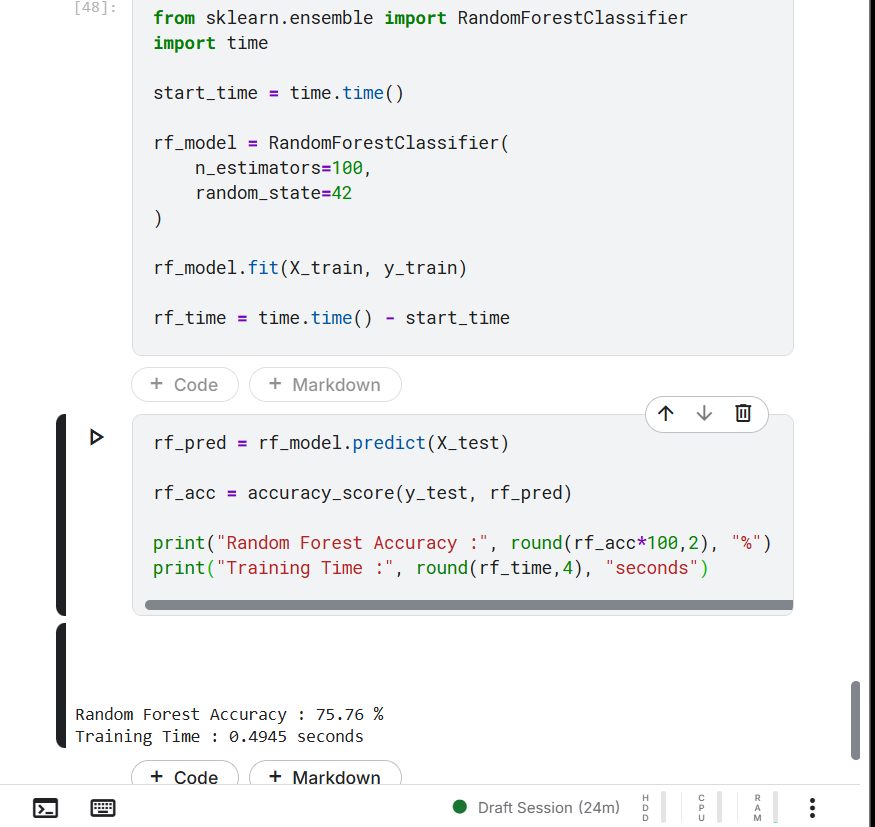

In [51]:
from sklearn.svm import SVC
import time

start_time = time.time()

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

svm_time = time.time() - start_time

In [52]:
svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", round(svm_acc*100,2), "%")
print("Training Time :", round(svm_time,4), "seconds")

SVM Accuracy : 63.64 %
Training Time : 0.0663 seconds


**Final Results Table**

In [53]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy (%)": [
        round(lr_acc*100,2),
        round(rf_acc*100,2),
        round(svm_acc*100,2)
    ]
})

results

,Model,Accuracy (%)
0,Logistic Regression,72.73
1,Random Forest,75.76
2,SVM,63.64


**Accuracy Comparison Graph**

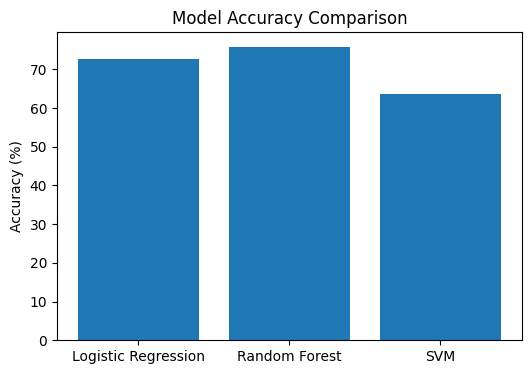

In [54]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

## Conclusion

In this project, facial emotion images were classified into Happy and Sad categories using three machine learning algorithms.

The dataset contained 165 facial images, including 92 happy faces and 73 sad faces.

The following models were trained and evaluated:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

Among all models, Random Forest achieved the highest accuracy of 75.76%, making it the best-performing model for this dataset.

The results demonstrate that ensemble learning techniques can effectively classify facial emotions from image data.